#### Installation and Deployment Steps for Kubernetes with Cloud AI 100

Copyright (c) 2025 Qualcomm Innovation Center, Inc. All rights reserved.<br>
SPDX-License-Identifier: BSD-3-Clause-Clear


##### Check installed SDK versions and available AIC devices

In [ ]:
# Check version of Platform SDK and App SDK
!/opt/qti-aic/tools/qaic-version-util

In [ ]:
# Check available AIC 100 devices
!/opt/qti-aic/tools/qaic-util -q

##### Build Docker for QAIC K8s Device Plugin

Execute the “build_image.sh” script which is located at “PATH_TO_QAIC_APP_SDK/qaic-apps-1.xx.x.x/common/tools/k8s-device-plugin”.<br>

This command accepts either aarch64 or x86_64 as an argument. If the architecture is not specified, the build script automatically detects it by executing "uname -p".

In [ ]:
#Build Docker Image for QAIC K8s Device Plugin
!bash PATH_TO_QAIC_APP_SDK/qaic-apps-1.xx.x.x/common/tools/k8s-device-plugin/build_image.sh

In [4]:
# check available docker image
!docker images

REPOSITORY               TAG       IMAGE ID       CREATED          SIZE
qaic-k8s-device-plugin   v1.1.0    0f7122ef4466   16 minutes ago   201MB


##### Build QAIC docker image

Update the zip file path for the QAIC Platform SDK and QAIC App SDK in the "user_image_spec_qaic.json" file located at "qaic-apps-1.xx.x.x/common/tools/docker-build/sample_user_specs".<br>

Build the QAIC Docker image using the Python script "build_image.py" located at "PATH_TO_QAIC_APP_SDK/qaic-apps-1.xx.x.x/common/tools/docker-build".

In [ ]:
!python PATH_TO_QAIC_APP_SDK/qaic-apps-1.xx.x.x/common/tools/docker-build/build_image.py --log_level 2 --user_specification_file PATH_TO_QAIC_APP_SDK/qaic-apps-1.xx.x.x/common/tools/docker-build/sample_user_specs/user_image_spec_qaic.json --apps_sdk PATH_TO_QAIC_APP_SDK_ZIP/qaic-apps-1.xx.x.x.zip --platform_sdk PATH_TO_QAIC_PLATFORM_SDK_ZIP/qaic-platform-sdk-1.xx.x.x.zip --tag latest

In [7]:
# Check Whether Both Docker Images for QAIC and K8s Plugin Are Available
!docker images

REPOSITORY                                                  TAG       IMAGE ID       CREATED          SIZE
qaic-x86_64-ubuntu20-py38-release-qaic_platform-qaic_apps   latest    510f29ed9b08   6 minutes ago    1.44GB
qaic-k8s-device-plugin                                      v1.1.0    6a2a19cdba0c   47 minutes ago   235MB


##### Installation of kubectl and minikube

Install kubectl and Minikube using the steps mentioned in the link below:

https://kubernetes.io/docs/tasks/tools/#install-kubectl-on-linux

Verify the successful installation of Minikube and kubectl using the commands below:

In [8]:
# verify successful installation of minikube
!minikube --help

minikube provisions and manages local Kubernetes clusters optimized for
development workflows.

Basic Commands:
  start            Starts a local Kubernetes cluster
  status           Gets the status of a local Kubernetes cluster
  stop             Stops a running local Kubernetes cluster
  delete           Deletes a local Kubernetes cluster
  dashboard        Access the Kubernetes dashboard running within the minikube
cluster
  pause            pause Kubernetes
  unpause          unpause Kubernetes

Images Commands:
  docker-env       Provides instructions to point your terminal's docker-cli to
the Docker Engine inside minikube. (Useful for building docker images directly
inside minikube)
  podman-env       Configure environment to use minikube's Podman service
  cache            Manage cache for images
  image            Manage images

Configuration and Management Commands:
  addons           Enable or disable a minikube addon
  config           Modify persistent configuration values

In [9]:
# verify successful installation of kubectl
!kubectl --help 

kubectl controls the Kubernetes cluster manager.

 Find more information at: https://kubernetes.io/docs/reference/kubectl/

Basic Commands (Beginner):
  create          Create a resource from a file or from stdin
  expose          Take a replication controller, service, deployment or pod and
expose it as a new Kubernetes service
  run             Run a particular image on the cluster
  set             Set specific features on objects

Basic Commands (Intermediate):
  explain         Get documentation for a resource
  get             Display one or many resources
  edit            Edit a resource on the server
  delete          Delete resources by file names, stdin, resources and names, or
by resources and label selector

Deploy Commands:
  rollout         Manage the rollout of a resource
  scale           Set a new size for a deployment, replica set, or replication
controller
  autoscale       Auto-scale a deployment, replica set, stateful set, or
replication controller

Cluster Manage

##### cri-dockerd installation

Follow the installation steps mentioned below from the system terminal.

##### cni installation

Follow the installation steps mentioned below from the system terminal.

In [10]:
#command to allow privileged processes to use files owned by non-privileged users.
!sysctl fs.protected_regular=0

fs.protected_regular = 0


In [11]:
#command to ensure that packets traversing the bridge are processed by iptables.
!echo 1 > /proc/sys/net/bridge/bridge-nf-call-iptables

##### Start a Kubernetes cluster

In [12]:
!minikube start --driver=none

😄  minikube v1.32.0 on Ubuntu 20.04
✨  Using the none driver based on user configuration
👍  Starting control plane node minikube in cluster minikube
🤹  Running on localhost (CPUs=48, Memory=515908MB, Disk=80514MB) ...
ℹ️  OS release is Ubuntu 20.04.6 LTS
🐳  Preparing Kubernetes v1.28.3 on Docker 27.3.1 ...
    ▪ kubelet.resolv-conf=/run/systemd/resolve/resolv.conf
    ▪ Generating certificates and keys ...
    ▪ Booting up control plane ...
    ▪ Configuring RBAC rules ...
🔗  Configuring bridge CNI (Container Networking Interface) ...
🤹  Configuring local host environment ...

❗  The 'none' driver is designed for experts who need to integrate with an existing VM
💡  Most users should use the newer 'docker' driver instead, which does not require root!
📘  For more information, see: https://minikube.sigs.k8s.io/docs/reference/drivers/none/

❗  kubectl and minikube configuration will be stored in /root
❗  To use kubectl or minikube commands as your own user, you may need to relocate them. F

##### Install device plugin

The QAIC device plugin file qaic-device-plugin.yml is located at qaic-apps-1.xx.x.x/common/tools/k8s-device-plugin.<br>

In the qaic-device-plugin.yml file, set the QAIC_SKU_BASED_RESOURCE_ENABLED flag to enable allocation of resources based on SKU. If this flag is not set, it does not check the type of SKU present; it simply allocates the available resources.<br>

Verify the Docker image name and tag of the QAIC K8s device plugin as shown in the following screenshot.<br>

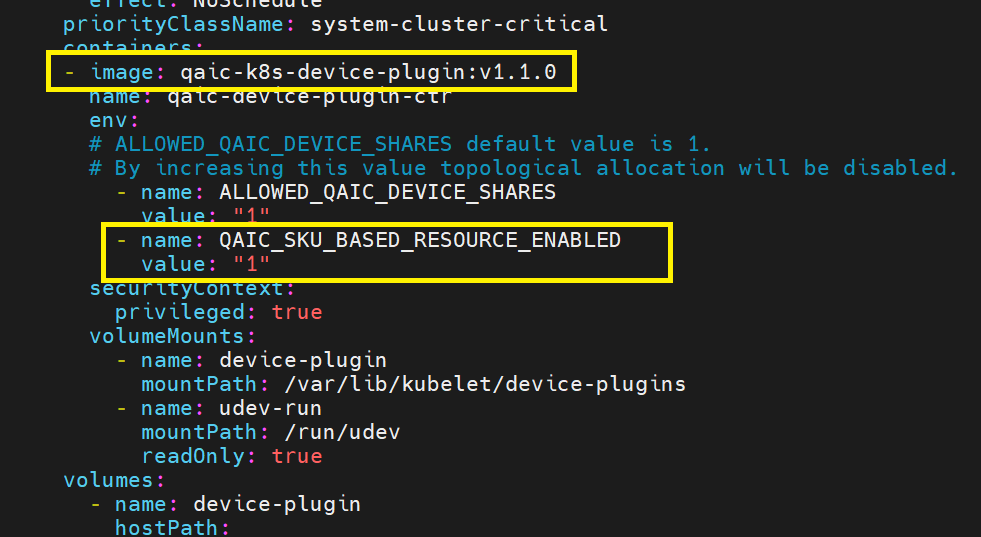

In [14]:
!kubectl create -f qaic-device-plugin.yml

daemonset.apps/qaic-device-plugin-daemonset created


##### Allocation of cloud AI 100 resources

Allocation can be done either using "qaic" or based on "qaic-<sku> (std | pro | ultra)".<br>
"qaic" setting doesn't look for what type of SKU is present, it just allocates the available resources.<br>
"qaic-sku" setting will help to allocate resources based on SKU.

##### Create Deployment

"deploy-qaic-single.yaml" file is located at "qaic-apps-1.xx.x.x/common/tools/k8s-device-plugin".<br>

Update the Docker image name for the qaic_platform-qaic_apps Docker image in the deploy-qaic-single.yaml file as shown in the screenshot below. Also, verify the number of QAIC devices along with the group ID and user ID with which the container is deployed..<br>

In the deploy-qaic-single.yaml file, specify the devices that's supported, like qaic | qaic-std | qaic-pro | qaic-ultra.

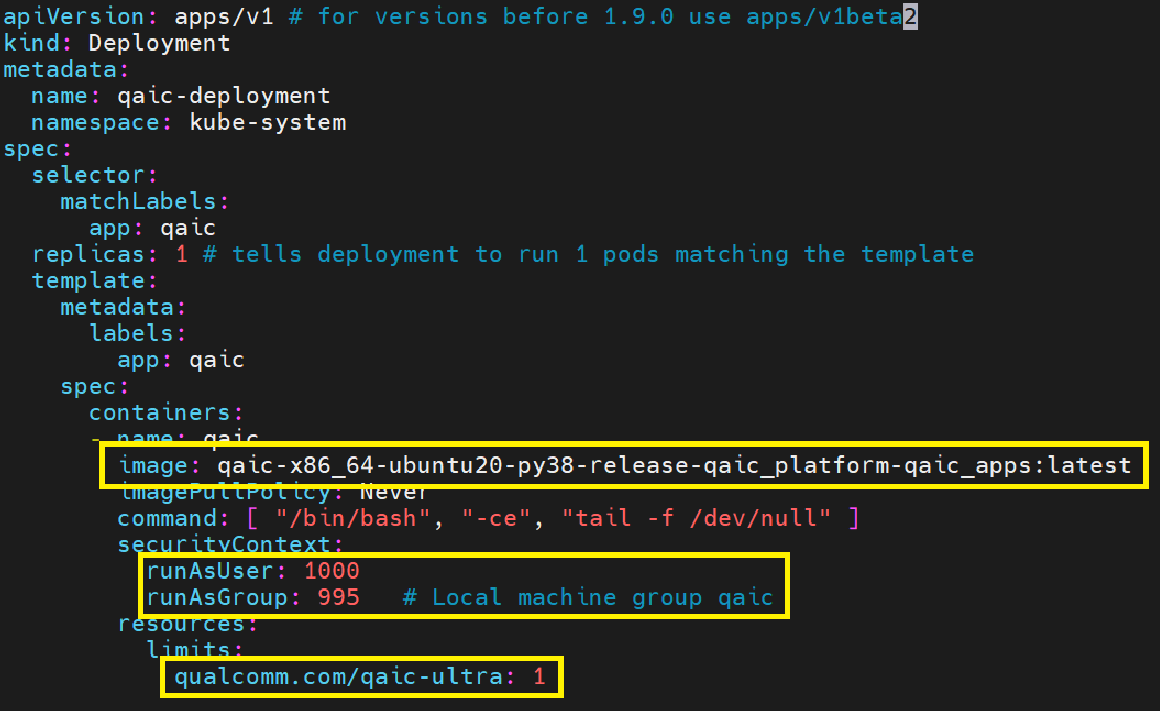

In [15]:
!kubectl apply --filename=./deploy-qaic-single.yaml --record=true

Flag --record has been deprecated, --record will be removed in the future
deployment.apps/qaic-deployment created


In [16]:
#configure the namespace
!kubectl config set-context --current --namespace=kube-system

Context "minikube" modified.


In [17]:
# list down pods
!kubectl get pods

NAME                                       READY   STATUS             RESTARTS        AGE
coredns-5dd5756b68-f85mk                   0/1     CrashLoopBackOff   20 (106s ago)   81m
etcd-qrc706r11-282-07                      1/1     Running            7               81m
kube-apiserver-qrc706r11-282-07            1/1     Running            7               81m
kube-controller-manager-qrc706r11-282-07   1/1     Running            7               81m
kube-proxy-cnf8x                           1/1     Running            0               81m
kube-scheduler-qrc706r11-282-07            1/1     Running            7               81m
qaic-deployment-879f79fc5-nfk96            1/1     Running            0               15s
qaic-device-plugin-daemonset-p4ck5         1/1     Running            0               76m
storage-provisioner                        1/1     Running            0               81m


In [18]:
# check if the deployment is running
!kubectl get deployments | grep qaic

qaic-deployment   1/1     1            1           41s


##### Access AIC 100 Devices from Deployed Container

In [ ]:
# Access AIC 100 devices from the deployed container
!kubectl exec --stdin --tty qaic-deployment-879f79fc5-nfk96 -- /opt/qti-aic/tools/qaic-util -q